# 🎭 Twitter Sentiment Analysis — Intermediate NLP Project

**Datasets used:**
- `train.csv` — 27k tweets, 3-class labels (positive / negative / neutral)
- `test.csv` — 4.8k tweets evaluation set  
- `testdata_manual_2009_06_14.csv` — Sentiment140 manual benchmark
- `training_1600000_processed_noemoticon.csv` — 1.6M Sentiment140 corpus (sample peek)

**Pipeline:** EDA → Preprocessing → TF-IDF Features → 4 Models → Evaluation → Deployment Demo

In [1]:
%matplotlib inline
import os, re, string, warnings, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("WordCloud not installed — pip install wordcloud")

# NLTK
import nltk
for pkg in ['stopwords', 'punkt', 'wordnet', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

try:
    from nltk.corpus import stopwords as sw
    from nltk.stem import PorterStemmer, WordNetLemmatizer
    from nltk.tokenize import word_tokenize
    STOPWORDS = set(sw.words('english'))
    KEEP = {'no','not',"don't","doesn't","won't","can't","shouldn't",'never'}
    STOPWORDS -= KEEP
    lemmatizer = WordNetLemmatizer()
    NLTK_OK = True
except Exception as e:
    print(f"NLTK limited: {e}")
    STOPWORDS = set()
    NLTK_OK = False

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

import sklearn
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
PALETTE = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}
sns.set_theme(style='whitegrid', font_scale=1.1)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print(f"✅ Libraries loaded  |  sklearn {sklearn.__version__}  |  pandas {pd.__version__}")
print(f"   NLTK ready: {NLTK_OK}  |  WordCloud: {WORDCLOUD_AVAILABLE}")

[nltk_data] Error loading stopwords: HTTP Error 403: Forbidden
[nltk_data] Error loading punkt: HTTP Error 403: Forbidden
[nltk_data] Error loading wordnet: HTTP Error 403: Forbidden
[nltk_data] Error loading punkt_tab: HTTP Error 403: Forbidden


NLTK limited: 
**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************

✅ Libraries loaded  |  sklearn 1.8.0  |  pandas 3.0.2
   NLTK ready: False  |  WordCloud: True


## 📂 1. Data Loading

In [2]:
# ── Paths — update if your CSVs live elsewhere ──────────────────────────────
def find(local, upload):
    return upload if os.path.exists(upload) else local

TRAIN_PATH  = find('data/train.csv',  '/mnt/user-data/uploads/train.csv')
TEST_PATH   = find('data/test.csv',   '/mnt/user-data/uploads/test.csv')
S140_PATH   = find('data/testdata_manual_2009_06_14.csv',
                   '/mnt/user-data/uploads/testdata_manual_2009_06_14.csv')
LARGE_PATH  = find('data/training_1600000_processed_noemoticon.csv',
                   '/mnt/user-data/uploads/training_1600000_processed_noemoticon.csv')

# ── Primary dataset (3-class) ──────────────────────────────────────────────
df_train = pd.read_csv(TRAIN_PATH, encoding='latin-1').dropna(subset=['text','sentiment']).reset_index(drop=True)
df_test  = pd.read_csv(TEST_PATH,  encoding='latin-1').dropna(subset=['text']).reset_index(drop=True)

print(f"Train : {df_train.shape}")
print(f"Test  : {df_test.shape}")
print(f"\nSentiment distribution:\n{df_train['sentiment'].value_counts()}")
df_train.head(3)

Train : (27480, 10)
Test  : (3534, 9)

Sentiment distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18


In [3]:
# ── Sentiment140 manual benchmark (binary) ────────────────────────────────
s140_cols = ['target','ids','date','flag','user','text']
df_s140 = pd.read_csv(S140_PATH, encoding='latin-1', header=None, names=s140_cols)
df_s140['target'] = pd.to_numeric(df_s140['target'], errors='coerce')
df_s140 = df_s140.dropna(subset=['target']).copy()
df_s140['sentiment_label'] = df_s140['target'].astype(int).map({0:'negative', 4:'positive', 2:'neutral'})
print(f"Sentiment140 manual: {df_s140.shape}")
print(df_s140['sentiment_label'].value_counts())

Sentiment140 manual: (516, 7)
sentiment_label
positive    198
negative    178
neutral     140
Name: count, dtype: int64


In [4]:
# ── Quick sample of the 1.6M Sentiment140 corpus ─────────────────────────
df_large = pd.read_csv(
    LARGE_PATH, encoding='latin-1', header=None,
    names=s140_cols, skiprows=1, low_memory=False, nrows=3000
)
df_large['target'] = pd.to_numeric(df_large['target'], errors='coerce')
df_large = df_large.dropna(subset=['target','text']).copy()
df_large['sentiment_label'] = df_large['target'].astype(int).map({0:'negative',4:'positive',2:'neutral'})
print(f"1.6M dataset (3k sample): {df_large.shape}")
print(df_large['sentiment_label'].value_counts())

1.6M dataset (3k sample): (3000, 7)
sentiment_label
negative    3000
Name: count, dtype: int64


## 🔍 2. Exploratory Data Analysis

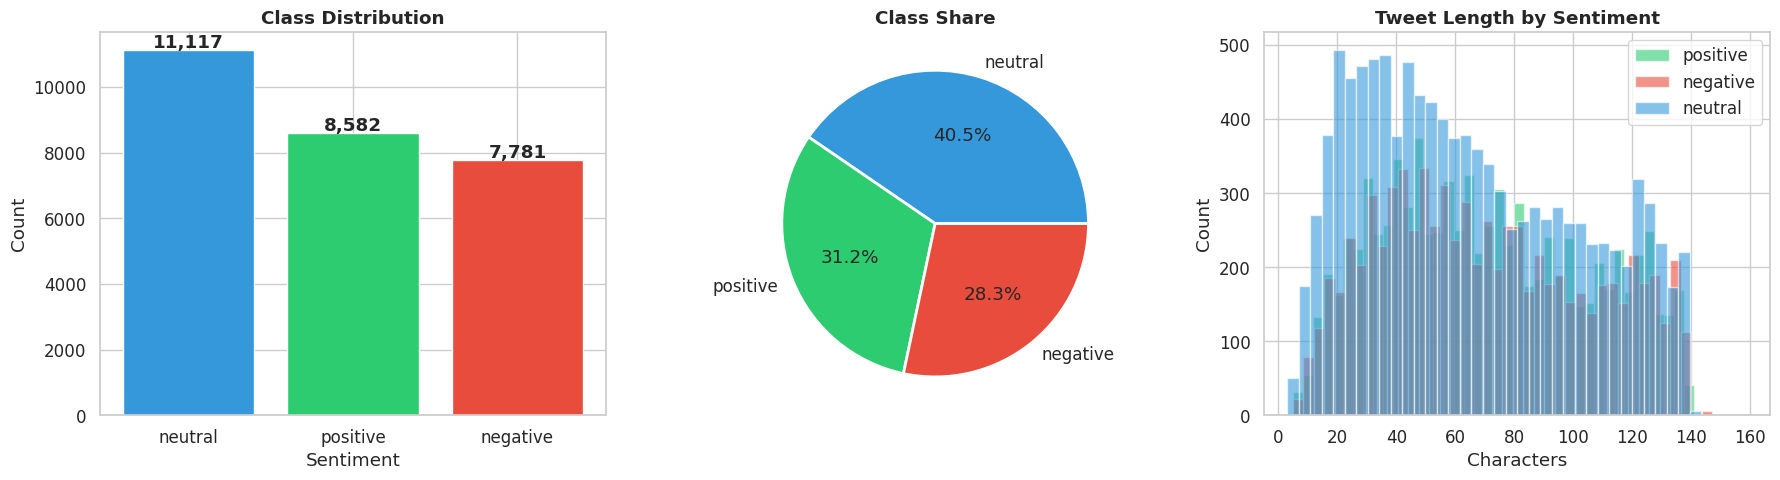

Saved: outputs/01_eda_overview.png


In [5]:
# ── Overview: distribution, pie, tweet length ─────────────────────────────
df_train['text_len'] = df_train['text'].astype(str).apply(len)
counts = df_train['sentiment'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE.get(s,'#95a5a6') for s in counts.index], edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE.get(s,'#95a5a6') for s in counts.index],
            autopct='%1.1f%%', wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Share', fontweight='bold')

# Length histogram
for s in ['positive','negative','neutral']:
    axes[2].hist(df_train[df_train['sentiment']==s]['text_len'],
                 bins=40, alpha=0.6, color=PALETTE[s], label=s, edgecolor='white')
axes[2].set_title('Tweet Length by Sentiment', fontweight='bold')
axes[2].set_xlabel('Characters'); axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/01_eda_overview.png")

             count  mean   std  min   25%   50%   75%    max
sentiment                                                   
negative    7781.0  70.5  35.2  5.0  42.0  66.0  98.0  147.0
neutral    11117.0  65.2  36.4  3.0  35.0  59.0  94.0  159.0
positive    8582.0  70.4  34.7  5.0  42.0  67.0  98.0  141.0


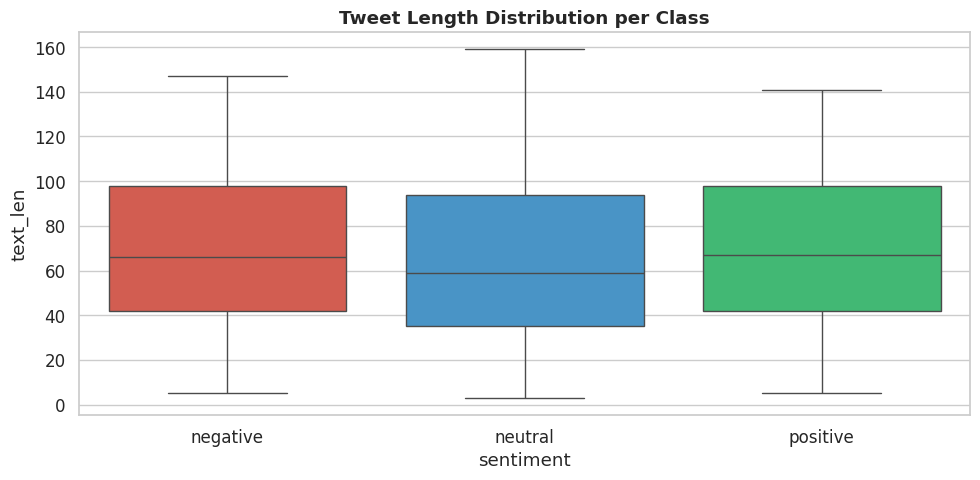

In [6]:
# ── Length stats + boxplot ────────────────────────────────────────────────
print(df_train.groupby('sentiment')['text_len'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_train, x='sentiment', y='text_len',
            palette=PALETTE, order=['negative','neutral','positive'], ax=ax)
ax.set_title('Tweet Length Distribution per Class', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_length_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

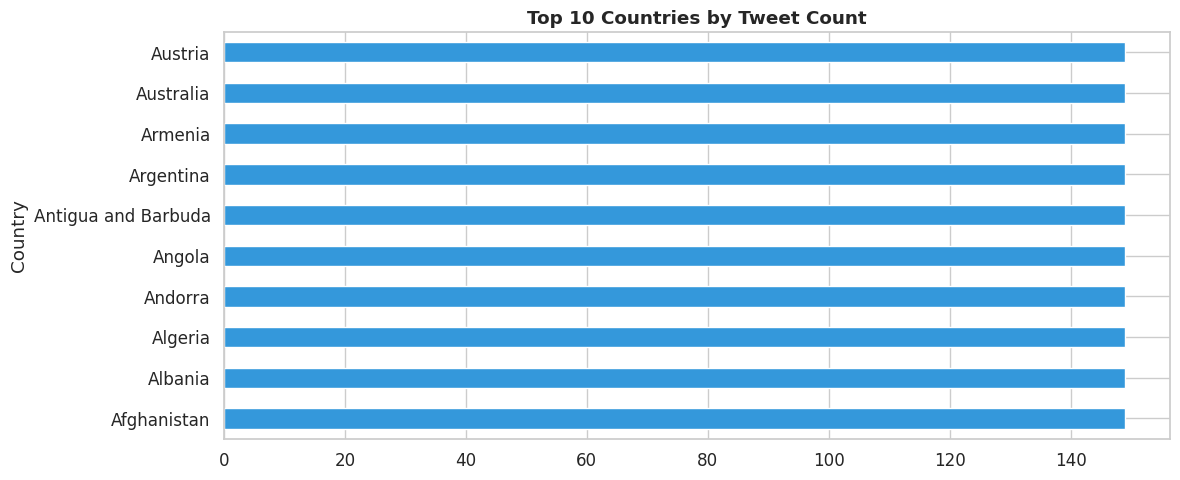

In [7]:
# ── Top countries ──────────────────────────────────────────────────────────
if 'Country' in df_train.columns:
    top_c = df_train['Country'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_c.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title('Top 10 Countries by Tweet Count', fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/03_top_countries.png', dpi=150, bbox_inches='tight')
    plt.show()

## 🧹 3. Text Preprocessing

In [8]:
def clean_tweet(text: str) -> str:
    """Full tweet cleaning pipeline."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # keep hashtag text
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)       # remove non-ASCII
    text = re.sub(r'\d+', '', text)                   # remove digits
    text = text.translate(str.maketrans('','',string.punctuation))
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)      # reduce elongation
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    try:
        tokens = word_tokenize(text)
    except Exception:
        tokens = text.split()
    
    # Remove stopwords
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    
    # Lemmatize
    if NLTK_OK:
        try:
            tokens = [lemmatizer.lemmatize(t) for t in tokens]
        except Exception:
            pass
    
    return ' '.join(tokens)

# Demo
samples = [
    "I looooove this new product!! 😍 http://t.co/xyz #amazing @Apple",
    "@user This is the WORST experience EVER!!! Can't believe it 😤",
    "Just another ordinary Tuesday. Nothing special today.",
]
print("BEFORE → AFTER preprocessing:\n")
for s in samples:
    print(f"  IN : {s}")
    print(f"  OUT: {clean_tweet(s)}")
    print()

BEFORE → AFTER preprocessing:

  IN : I looooove this new product!! 😍 http://t.co/xyz #amazing @Apple
  OUT: loove this new product amazing

  IN : @user This is the WORST experience EVER!!! Can't believe it 😤
  OUT: this is the worst experience ever cant believe it

  IN : Just another ordinary Tuesday. Nothing special today.
  OUT: just another ordinary tuesday nothing special today



In [9]:
# ── Apply to full dataset ─────────────────────────────────────────────────
print("Cleaning train...")
df_train['clean_text'] = df_train['text'].apply(clean_tweet)
print("Cleaning test...")
df_test['clean_text']  = df_test['text'].apply(clean_tweet)

df_train = df_train[df_train['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f"\n✅ Train after cleaning: {len(df_train):,} rows")
df_train[['text','clean_text','sentiment']].head(4)

Cleaning train...


Cleaning test...



✅ Train after cleaning: 27,475 rows


,text,clean_text,sentiment
0,"I`d have responded, if I were going",id have responded if were going,neutral
1,Sooo SAD I will miss you here in San Diego!!!,soo sad will miss you here in san diego,negative
2,my boss is bullying me...,my boss is bullying me,negative
3,what interview! leave me alone,what interview leave me alone,negative


## ☁️ 4. Word Clouds & Top Bigrams

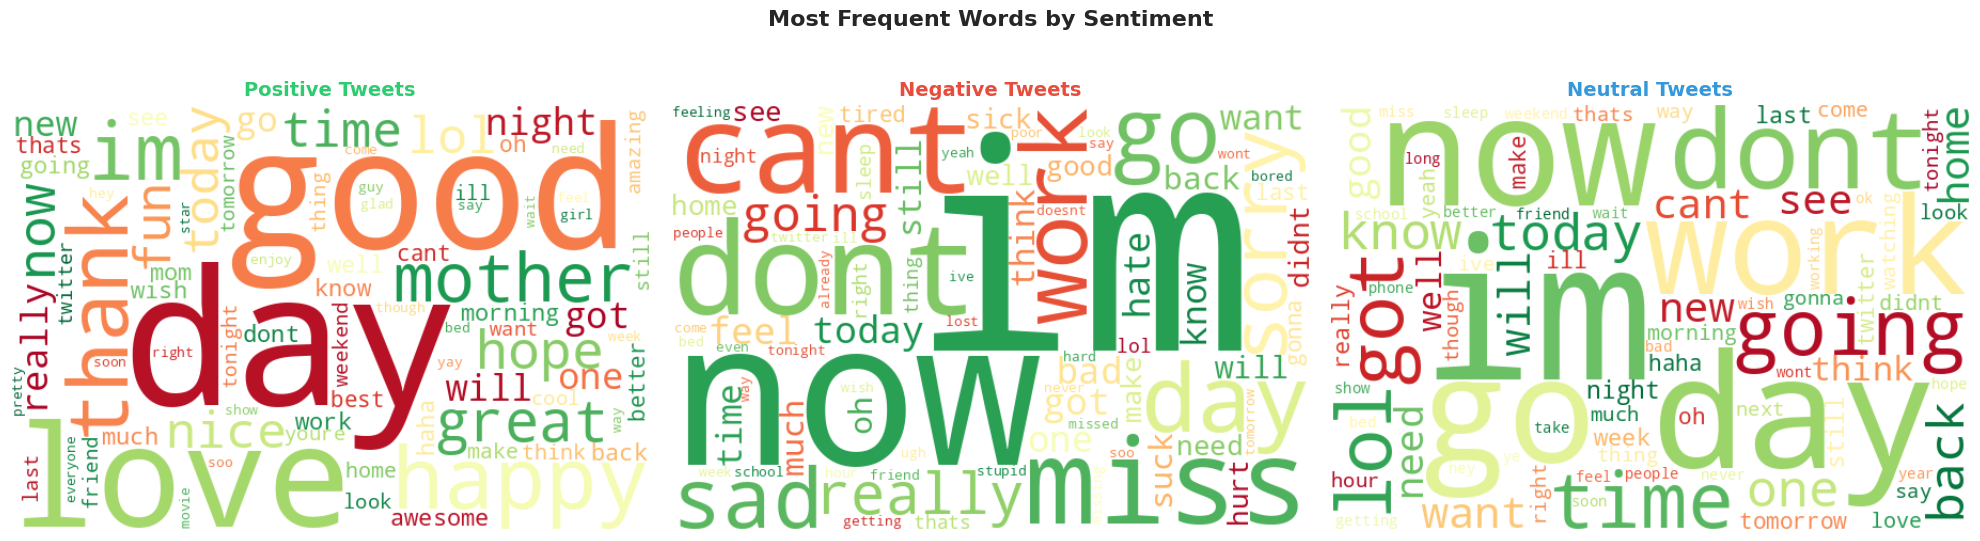

In [10]:
if WORDCLOUD_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, s in zip(axes, ['positive','negative','neutral']):
        corpus = ' '.join(df_train[df_train['sentiment']==s]['clean_text'])
        if corpus.strip():
            wc = WordCloud(width=600, height=400, background_color='white',
                           colormap='RdYlGn', max_words=80, collocations=False).generate(corpus)
            ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{s.title()} Tweets', fontweight='bold', color=PALETTE[s], fontsize=14)
    plt.suptitle('Most Frequent Words by Sentiment', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/04_wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("pip install wordcloud  →  then re-run this cell")

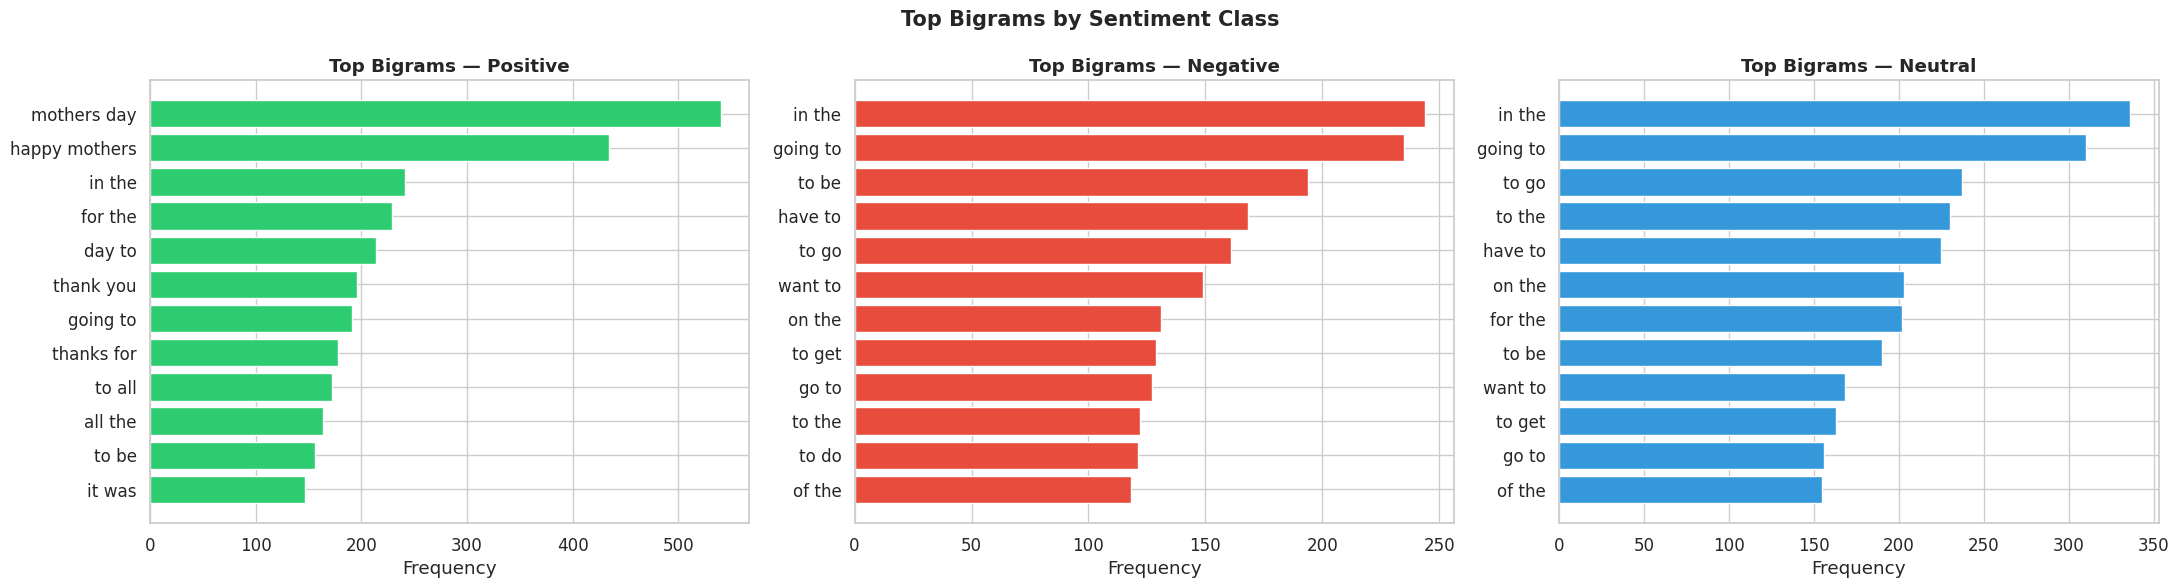

In [11]:
# ── Top bigrams per class ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, s in zip(axes, ['positive','negative','neutral']):
    corpus = df_train[df_train['sentiment']==s]['clean_text'].tolist()
    vec = CountVectorizer(ngram_range=(2,2), max_features=500)
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    top = sorted(zip(vec.get_feature_names_out(), freqs), key=lambda x:-x[1])[:12]
    if top:
        labels, vals = zip(*top)
        ax.barh(list(labels)[::-1], list(vals)[::-1], color=PALETTE[s], edgecolor='white')
    ax.set_title(f'Top Bigrams — {s.title()}', fontweight='bold')
    ax.set_xlabel('Frequency')
plt.suptitle('Top Bigrams by Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_top_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ 5. Feature Engineering (TF-IDF vs BoW)

In [12]:
# ── Label encoding & train/val split ─────────────────────────────────────
le = LabelEncoder()
y_all = le.fit_transform(df_train['sentiment'])
label_names = le.classes_
print("Label encoding:", dict(zip(label_names, le.transform(label_names))))

X_text = df_train['clean_text'].values
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)
print(f"\nTrain: {len(X_train_text):,}  |  Validation: {len(X_val_text):,}")

Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Train: 21,980  |  Validation: 5,495


In [13]:
# ── TF-IDF (unigrams + bigrams) ───────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=2, strip_accents='unicode')
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)

# ── BoW ───────────────────────────────────────────────────────────────────
bow = CountVectorizer(max_features=50_000, ngram_range=(1,2), min_df=2)
X_train_bow = bow.fit_transform(X_train_text)
X_val_bow   = bow.transform(X_val_text)

print(f"TF-IDF matrix : {X_train_tfidf.shape}")
print(f"BoW matrix    : {X_train_bow.shape}")

TF-IDF matrix : (21980, 31120)
BoW matrix    : (21980, 31120)


## 🤖 6. Model Training & Comparison

In [14]:
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=500, C=1.0, solver='lbfgs',
                                               random_state=RANDOM_STATE),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVC':          LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                   random_state=RANDOM_STATE),
}

results = []; trained_models = {}

for name, model in MODELS.items():
    print(f"Training {name}...", end="  ")
    model.fit(X_train_tfidf, y_train)
    y_pred  = model.predict(X_val_tfidf)
    acc     = accuracy_score(y_val, y_pred)
    f1_mac  = f1_score(y_val, y_pred, average='macro')
    f1_wt   = f1_score(y_val, y_pred, average='weighted')
    results.append({'Model':name,'Accuracy':acc,'F1-Macro':f1_mac,'F1-Weighted':f1_wt})
    trained_models[name] = model
    print(f"Accuracy: {acc:.4f}  F1-Macro: {f1_mac:.4f}")

results_df = pd.DataFrame(results).sort_values('F1-Macro', ascending=False)
print("\n=== Leaderboard ===")
print(results_df.to_string(index=False))

Training Logistic Regression...  

Accuracy: 0.6808  F1-Macro: 0.6819
Training Naive Bayes...  Accuracy: 0.6291  F1-Macro: 0.6306
Training Linear SVC...  

Accuracy: 0.6732  F1-Macro: 0.6758
Training Random Forest...  

Accuracy: 0.6741  F1-Macro: 0.6693

=== Leaderboard ===
              Model  Accuracy  F1-Macro  F1-Weighted
Logistic Regression  0.680801  0.681860     0.681445
         Linear SVC  0.673157  0.675801     0.673367
      Random Forest  0.674067  0.669285     0.671864
        Naive Bayes  0.629117  0.630579     0.629845


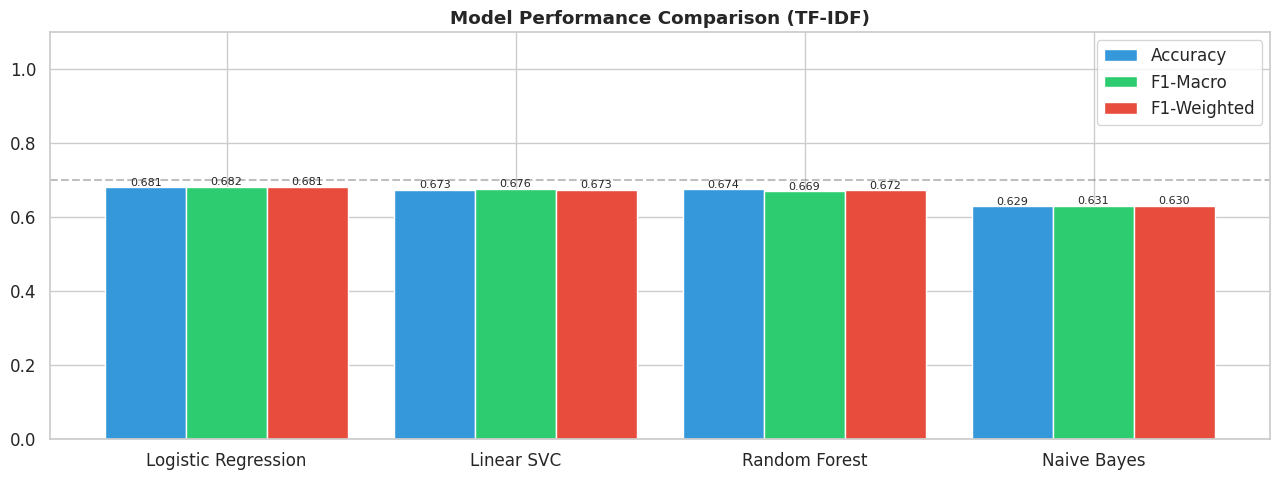

In [15]:
# ── Grouped bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_df)); w = 0.28
b1 = ax.bar(x-w,   results_df['Accuracy'],    w, label='Accuracy',    color='#3498db')
b2 = ax.bar(x,     results_df['F1-Macro'],    w, label='F1-Macro',    color='#2ecc71')
b3 = ax.bar(x+w,   results_df['F1-Weighted'], w, label='F1-Weighted', color='#e74c3c')
for bars in [b1,b2,b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(results_df['Model']); ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison (TF-IDF)', fontweight='bold')
ax.legend(); ax.axhline(0.7, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('outputs/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── TF-IDF vs BoW on Logistic Regression ─────────────────────────────────
lr_t = LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE)
lr_b = LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE)
lr_t.fit(X_train_tfidf, y_train); lr_b.fit(X_train_bow, y_train)
print(f"Logistic Regression — TF-IDF accuracy : {accuracy_score(y_val, lr_t.predict(X_val_tfidf)):.4f}")
print(f"Logistic Regression — BoW accuracy    : {accuracy_score(y_val, lr_b.predict(X_val_bow)):.4f}")

Logistic Regression — TF-IDF accuracy : 0.6808
Logistic Regression — BoW accuracy    : 0.6855


## 📊 7. Detailed Report — Best Model

In [17]:
best_name   = results_df.iloc[0]['Model']
best_model  = trained_models[best_name]
y_pred_best = best_model.predict(X_val_tfidf)

print(f"🏆 Best Model: {best_name}\n")
print(classification_report(y_val, y_pred_best, target_names=label_names))

🏆 Best Model: Logistic Regression

              precision    recall  f1-score   support

    negative       0.72      0.60      0.65      1556
     neutral       0.61      0.74      0.67      2223
    positive       0.77      0.69      0.73      1716

    accuracy                           0.68      5495
   macro avg       0.70      0.67      0.68      5495
weighted avg       0.69      0.68      0.68      5495



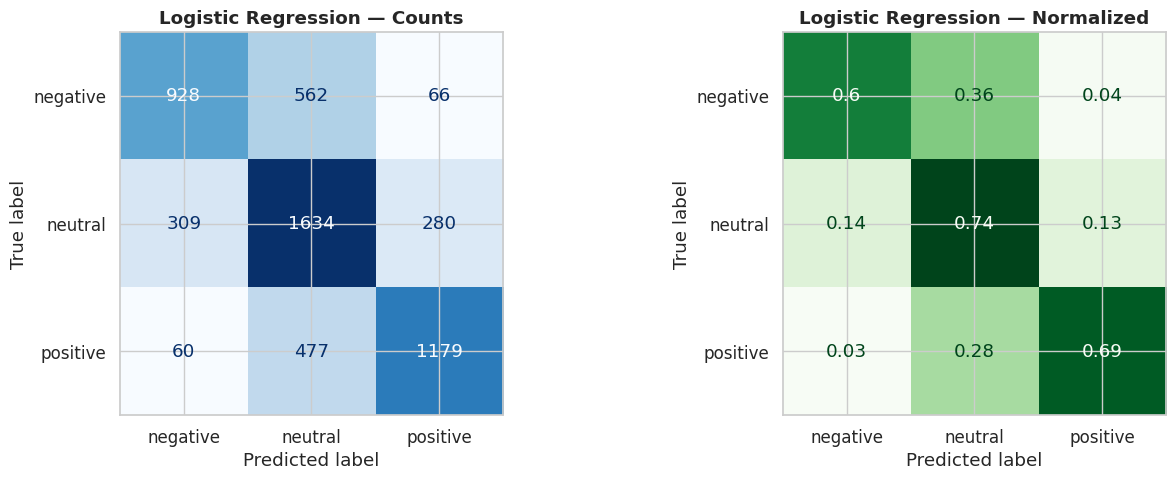

In [18]:
# ── Confusion matrices ────────────────────────────────────────────────────
cm = confusion_matrix(y_val, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_name} — Counts', fontweight='bold')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=label_names).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'{best_name} — Normalized', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

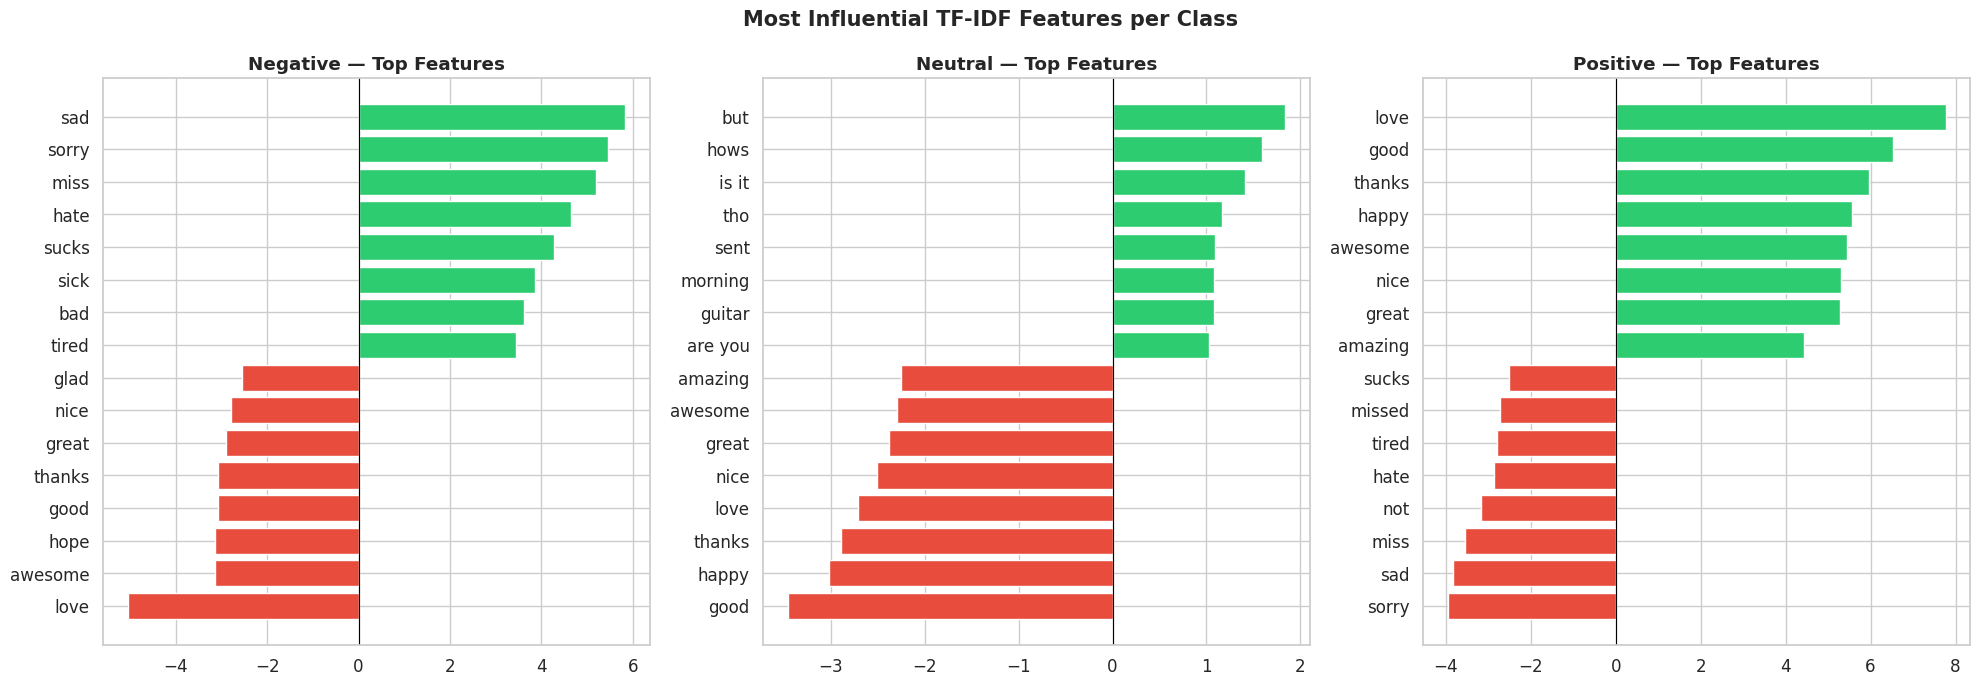

In [19]:
# ── Feature importance (Logistic Regression coefficients) ─────────────────
lr_model   = trained_models['Logistic Regression']
feat_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, ci, cn in zip(axes, range(3), label_names):
    coefs = lr_model.coef_[ci]
    top_i = coefs.argsort()[-8:][::-1]
    bot_i = coefs.argsort()[:8]
    idx = np.concatenate([top_i, bot_i])
    vals = coefs[idx]; feats = feat_names[idx]
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in vals]
    si = vals.argsort()
    ax.barh(feats[si], vals[si], color=[colors[i] for i in si])
    ax.set_title(f'{cn.title()} — Top Features', fontweight='bold')
    ax.axvline(0, color='black', lw=0.8)
plt.suptitle('Most Influential TF-IDF Features per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/08_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔁 8. Cross-Validation

Logistic Regression        CV F1-Macro: 0.6861 ± 0.0058


Naive Bayes                CV F1-Macro: 0.6258 ± 0.0075


Linear SVC                 CV F1-Macro: 0.6741 ± 0.0063


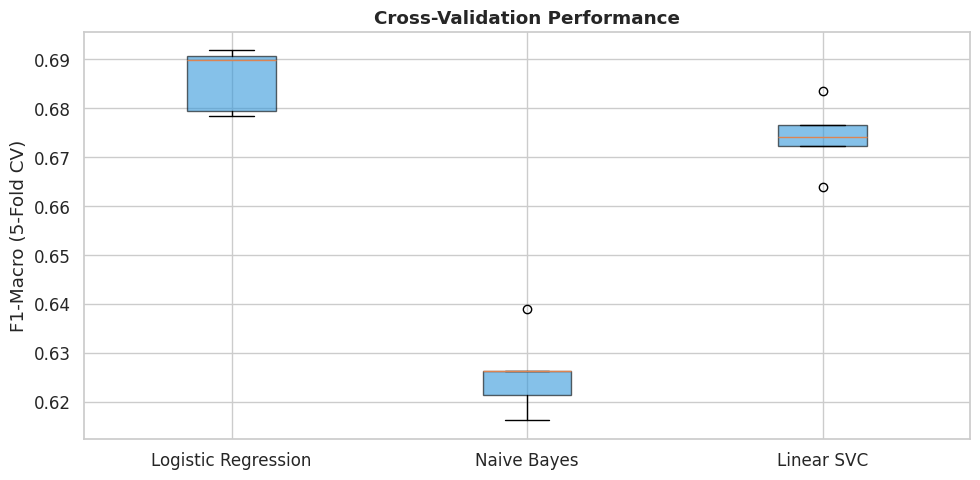

In [20]:
X_all_tfidf = tfidf.transform(X_text)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVC':          LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
}
cv_scores = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_all_tfidf, y_all, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name:25s}  CV F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_scores.values(), tick_labels=cv_scores.keys(),
           patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
ax.set_ylabel('F1-Macro (5-Fold CV)')
ax.set_title('Cross-Validation Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/09_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 🐛 9. Error Analysis

In [21]:
val_df = pd.DataFrame({
    'text':      X_val_text,
    'true':      le.inverse_transform(y_val),
    'predicted': le.inverse_transform(y_pred_best),
})
val_df['correct'] = val_df['true'] == val_df['predicted']

errors = val_df[~val_df['correct']]
print(f"Misclassified: {len(errors)} / {len(val_df)} ({len(errors)/len(val_df)*100:.1f}%)")
print("\nError breakdown:")
print(errors.groupby(['true','predicted']).size().reset_index(name='count')
              .sort_values('count', ascending=False).to_string(index=False))

Misclassified: 1754 / 5495 (31.9%)

Error breakdown:
    true predicted  count
negative   neutral    562
positive   neutral    477
 neutral  negative    309
 neutral  positive    280
negative  positive     66
positive  negative     60


In [22]:
print("=== Sample Misclassified Tweets ===\n")
for _, row in errors.sample(min(6, len(errors)), random_state=42).iterrows():
    print(f"  Text     : {row['text'][:90]}")
    print(f"  True     : {row['true']}  →  Predicted: {row['predicted']}")
    print("  " + "─"*60)

=== Sample Misclassified Tweets ===

  Text     : cant seem to find the new mountain dew throwback in packsonly in liter bottles
  True     : neutral  →  Predicted: negative
  ────────────────────────────────────────────────────────────
  Text     : super stressful day cant sleepglad found you your so sweet to take the time to make strang
  True     : neutral  →  Predicted: positive
  ────────────────────────────────────────────────────────────
  Text     : take it youre not fan
  True     : negative  →  Predicted: neutral
  ────────────────────────────────────────────────────────────
  Text     : funnily enough roland is president of my social club
  True     : positive  →  Predicted: neutral
  ────────────────────────────────────────────────────────────
  Text     : such busy day today banbury fair fashion show tonight and move into my apartment tomorrow 
  True     : negative  →  Predicted: neutral
  ────────────────────────────────────────────────────────────
  Text     : is chilli

## 💾 10. Save Model Pipeline

In [23]:
artifacts = {
    'model':         best_model,
    'vectorizer':    tfidf,
    'label_encoder': le,
    'model_name':    best_name,
    'label_names':   label_names.tolist(),
}
with open('models/sentiment_pipeline.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print(f"✅ Saved: models/sentiment_pipeline.pkl")
print(f"   Model : {best_name}")
print(f"   Labels: {label_names.tolist()}")

✅ Saved: models/sentiment_pipeline.pkl
   Model : Logistic Regression
   Labels: ['negative', 'neutral', 'positive']


## 🚀 11. Predict on Custom Text

In [24]:
def predict_sentiment(texts, pipeline_path='models/sentiment_pipeline.pkl'):
    """Predict sentiment for a list of raw tweet strings."""
    with open(pipeline_path, 'rb') as f:
        art = pickle.load(f)
    
    cleaned  = [clean_tweet(t) for t in texts]
    features = art['vectorizer'].transform(cleaned)
    preds    = art['model'].predict(features)
    labels   = art['label_encoder'].inverse_transform(preds)
    
    # Confidence
    if hasattr(art['model'], 'predict_proba'):
        probs = art['model'].predict_proba(features)
    elif hasattr(art['model'], 'decision_function'):
        df_s = art['model'].decision_function(features)
        e = np.exp(df_s - df_s.max(axis=1, keepdims=True))
        probs = e / e.sum(axis=1, keepdims=True)
    else:
        probs = None
    
    rows = []
    for i, (text, label) in enumerate(zip(texts, labels)):
        row = {'text': text[:80], 'sentiment': label}
        if probs is not None:
            for j, cls in enumerate(art['label_encoder'].classes_):
                row[f'prob_{cls}'] = round(float(probs[i, j]), 3)
        rows.append(row)
    return pd.DataFrame(rows)


test_tweets = [
    "Absolutely love the new iPhone update! Best phone ever 🎉",
    "This product is terrible and a complete waste of money. Avoid!",
    "Just got back from the supermarket. Bought some milk.",
    "Can't believe how amazing the concert was last night!! 🎶🔥",
    "The customer service was rude and unhelpful. Very disappointed.",
    "Weather is okay today. Not too hot, not too cold.",
    "Why would anyone release such a buggy app? Completely broken!!!",
    "Had an incredible sunset view today, so peaceful ☀️",
]

result_df = predict_sentiment(test_tweets)
print("=== Sentiment Predictions ===")
print(result_df.to_string(index=False))

=== Sentiment Predictions ===
                                                           text sentiment  prob_negative  prob_neutral  prob_positive
       Absolutely love the new iPhone update! Best phone ever 🎉  positive          0.007         0.076          0.916
 This product is terrible and a complete waste of money. Avoid!  negative          0.714         0.184          0.102
          Just got back from the supermarket. Bought some milk.   neutral          0.068         0.826          0.106
      Can't believe how amazing the concert was last night!! 🎶🔥  positive          0.132         0.324          0.544
The customer service was rude and unhelpful. Very disappointed.  negative          0.475         0.337          0.188
              Weather is okay today. Not too hot, not too cold.   neutral          0.334         0.558          0.109
Why would anyone release such a buggy app? Completely broken!!!   neutral          0.398         0.413          0.190
            Had an incredi

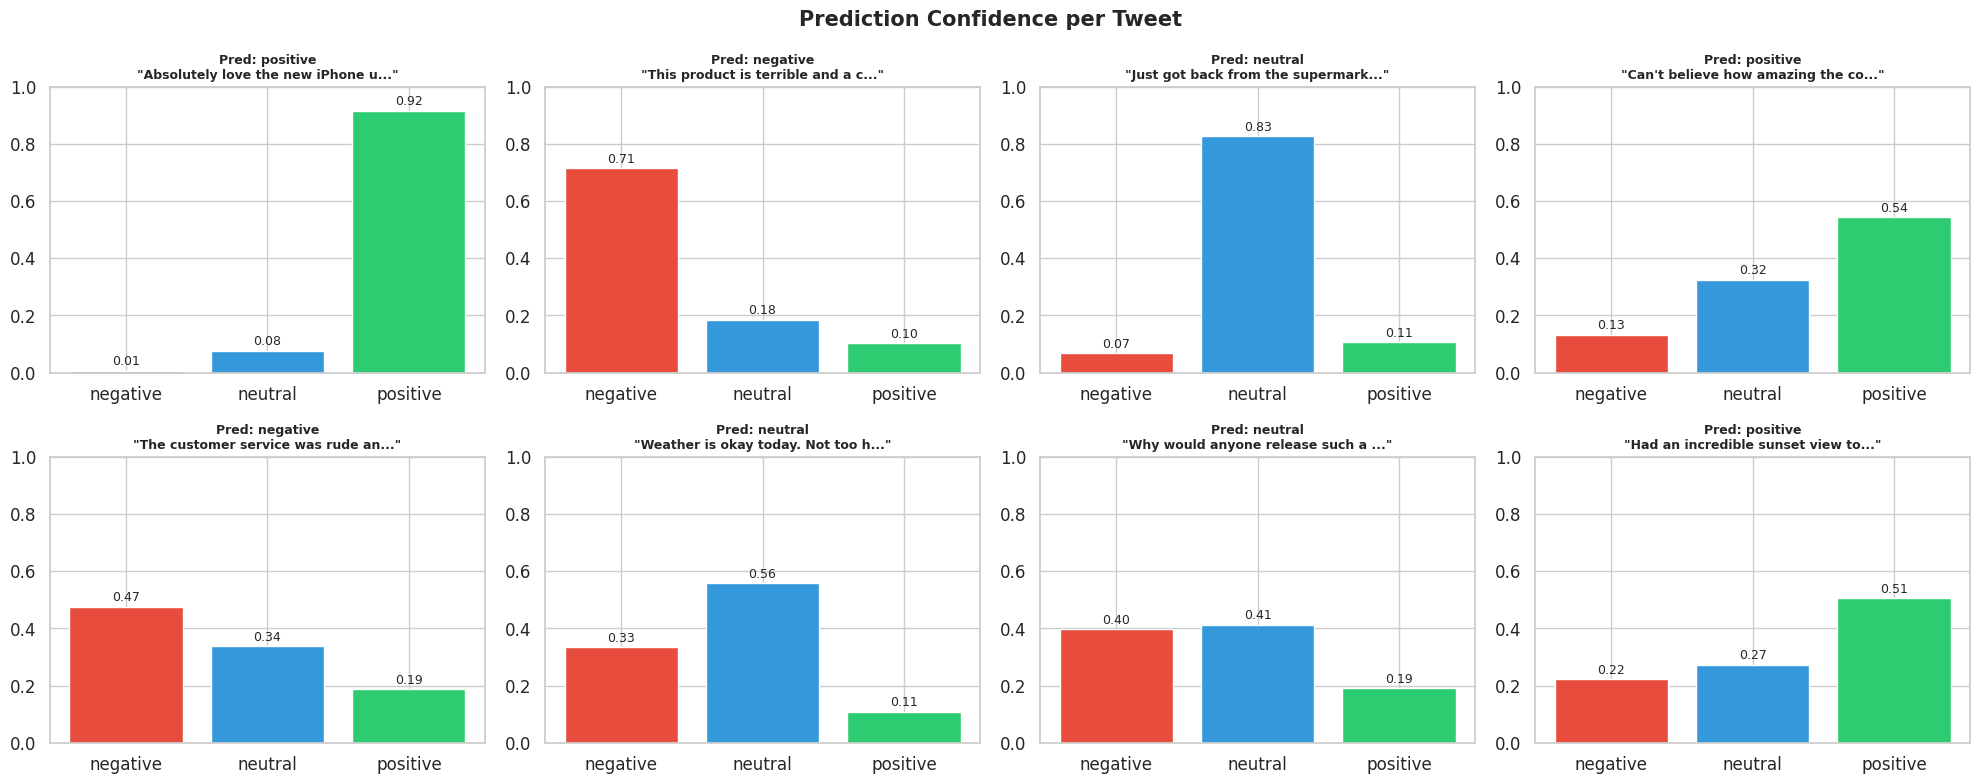

In [25]:
# ── Confidence bar chart ──────────────────────────────────────────────────
prob_cols = [c for c in result_df.columns if c.startswith('prob_')]
if prob_cols:
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()
    for i, (ax, row) in enumerate(zip(axes, result_df.itertuples())):
        probs = [getattr(row, col) for col in prob_cols]
        class_names = [c.replace('prob_','') for c in prob_cols]
        colors = [PALETTE.get(c,'#95a5a6') for c in class_names]
        bars = ax.bar(class_names, probs, color=colors, edgecolor='white')
        ax.set_ylim(0, 1)
        ax.set_title(f'Pred: {row.sentiment}\n"{row.text[:32]}..."', fontsize=9, fontweight='bold')
        for bar, prob in zip(bars, probs):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{prob:.2f}', ha='center', fontsize=9)
    plt.suptitle('Prediction Confidence per Tweet', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/10_prediction_confidence.png', dpi=150, bbox_inches='tight')
    plt.show()

## 📋 12. Final Summary

In [26]:
best_row = results_df.iloc[0]
print('=' * 58)
print('     SENTIMENT ANALYSIS — FINAL RESULTS SUMMARY')
print('=' * 58)
print(f'Dataset         : Kaggle Twitter Sentiment (train.csv)')
print(f'Training samples: {len(df_train):,}')
print(f'Classes         : {label_names.tolist()}')
print(f'Vectorizer      : TF-IDF  (unigrams + bigrams, 50K features)')
print()
print('Model Leaderboard:')
print(results_df.round(4).to_string(index=False))
print()
print(f'🏆 Best Model    : {best_row["Model"]}')
print(f'   Accuracy      : {best_row["Accuracy"]:.4f}')
print(f'   F1-Macro      : {best_row["F1-Macro"]:.4f}')
print(f'   F1-Weighted   : {best_row["F1-Weighted"]:.4f}')
print()
print('Outputs saved:')
for f in sorted(os.listdir('outputs')):
    print(f'  outputs/{f}')
print(f'  models/sentiment_pipeline.pkl')
print('=' * 58)

     SENTIMENT ANALYSIS — FINAL RESULTS SUMMARY
Dataset         : Kaggle Twitter Sentiment (train.csv)
Training samples: 27,475
Classes         : ['negative', 'neutral', 'positive']
Vectorizer      : TF-IDF  (unigrams + bigrams, 50K features)

Model Leaderboard:
              Model  Accuracy  F1-Macro  F1-Weighted
Logistic Regression    0.6808    0.6819       0.6814
         Linear SVC    0.6732    0.6758       0.6734
      Random Forest    0.6741    0.6693       0.6719
        Naive Bayes    0.6291    0.6306       0.6298

🏆 Best Model    : Logistic Regression
   Accuracy      : 0.6808
   F1-Macro      : 0.6819
   F1-Weighted   : 0.6814

Outputs saved:
  outputs/01_eda_overview.png
  outputs/02_length_boxplot.png
  outputs/03_top_countries.png
  outputs/04_wordclouds.png
  outputs/05_top_bigrams.png
  outputs/06_model_comparison.png
  outputs/07_confusion_matrix.png
  outputs/08_top_features.png
  outputs/09_cross_validation.png
  outputs/10_prediction_confidence.png
  models/sentiment

## ➕ Bonus: Hyperparameter Tuning (optional, ~5 min)

In [27]:
# Uncomment to run Grid Search on Logistic Regression

# from sklearn.model_selection import GridSearchCV
# param_grid = {'C': [0.01, 0.1, 1.0, 5.0, 10.0]}
# lr_gs = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
# grid = GridSearchCV(lr_gs, param_grid, scoring='f1_macro', cv=3, n_jobs=-1, verbose=1)
# grid.fit(X_train_tfidf, y_train)
# print('Best params:', grid.best_params_)
# print('Best F1-Macro:', grid.best_score_)

print("Uncomment the lines above to run Grid Search.")

Uncomment the lines above to run Grid Search.
